## `plot_crosscorr.py`

In [2]:
import fitsio as fio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cmocean.cm as cmo

from pathlib import Path
from pycorr import TwoPointCorrelationFunction, utils

import src.statistics.corrutils as cu
import src.statistics.cosmotools as ct
import importlib

cmap = cmo.thermal

In [48]:
from pycorr import utils
import cmocean.cm as cmo

importlib.reload(cu)
file_reader = cu.CorrFileReader('../crosscorr/corr24_sims1/')
tgt = 'LRG'
moc_idx = 0

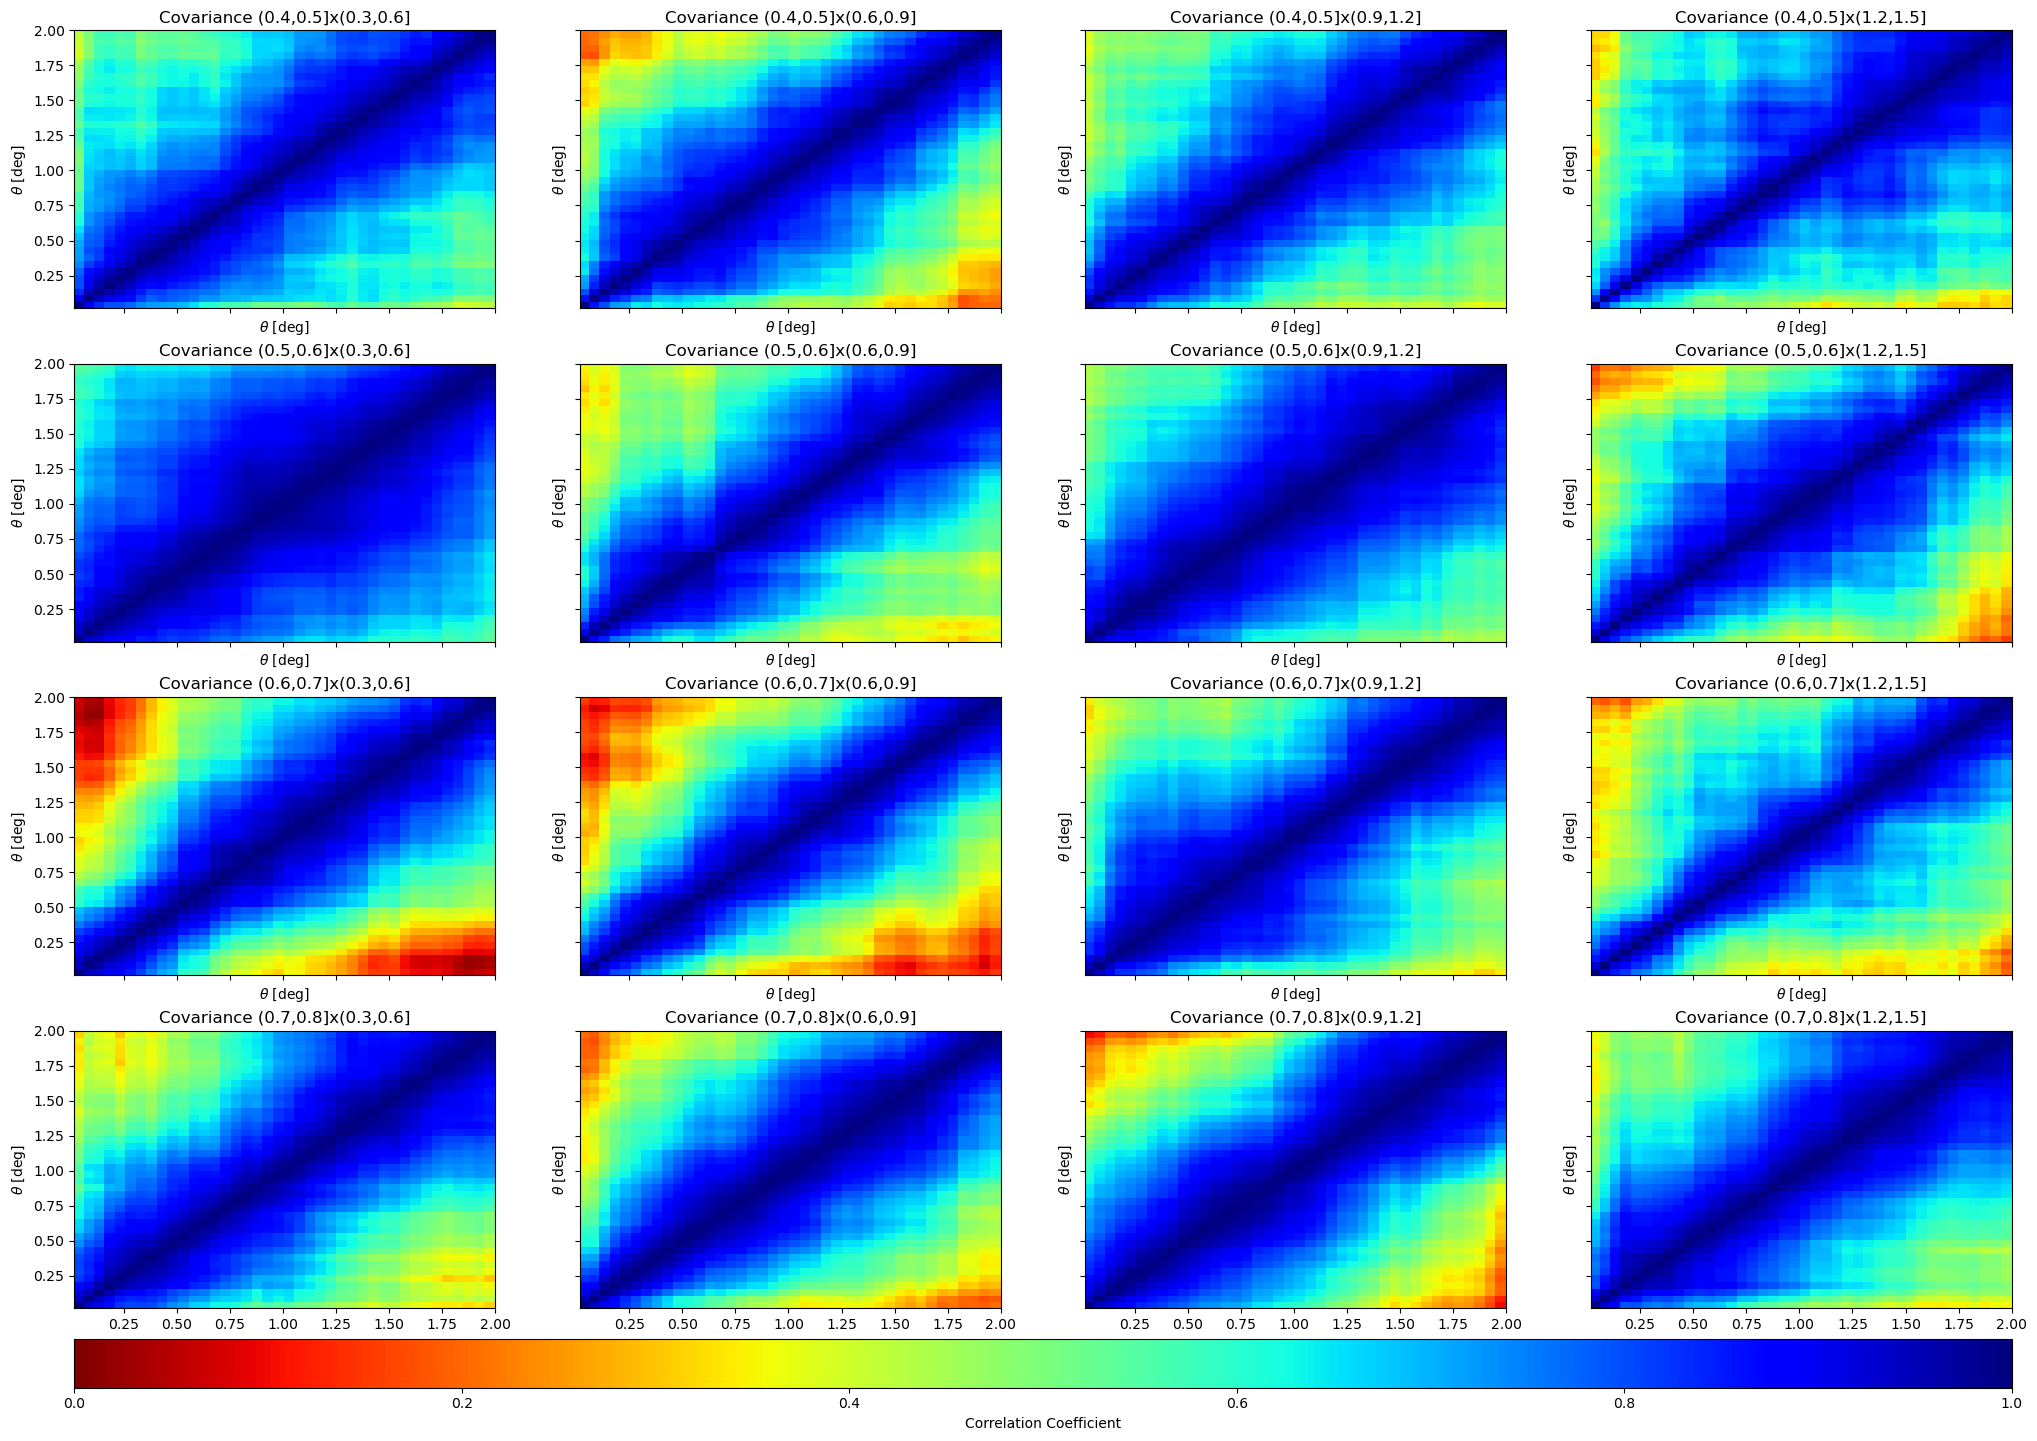

In [49]:
fig, axs = plt.subplots(4, 4, figsize=(25, 20), sharex=True, sharey=True)
bins_tgt = file_reader.get_bins(tgt)
bins_hsc = file_reader.get_bins('HSC')

for i in range(1, 5):
    for j in range(1, len(bins_hsc)):
        try:
            result = TwoPointCorrelationFunction.load(
                file_reader.get_file(i, j, tgt, 'HSC', moc_idx)
                )
        except FileNotFoundError:
            continue
        ax = axs[i-1, j-1]
        sep = result.sep
        cov = result.cov()

        corrcoef = utils.cov_to_corrcoef(result.cov())

        ax.pcolor(sep, sep, corrcoef.T, cmap=plt.get_cmap('jet_r'), vmin=0, vmax=1)
        ax.set_title(f'Covariance ({bins_tgt[i-1]:.1f},{bins_tgt[i]:.1f}]x({bins_hsc[j-1]:.1f},{bins_hsc[j]:.1f}]')
        ax.set_xlabel(r'$\theta$ [deg]')
        ax.set_ylabel(r'$\theta$ [deg]')

# Add a single colorbar for all subplots
cbar = fig.colorbar(
    axs[0, 0].collections[0], 
    ax=axs, 
    label="Correlation Coefficient", 
    orientation='horizontal', 
    pad=0.02, 
    aspect=40
    )

plt.show()

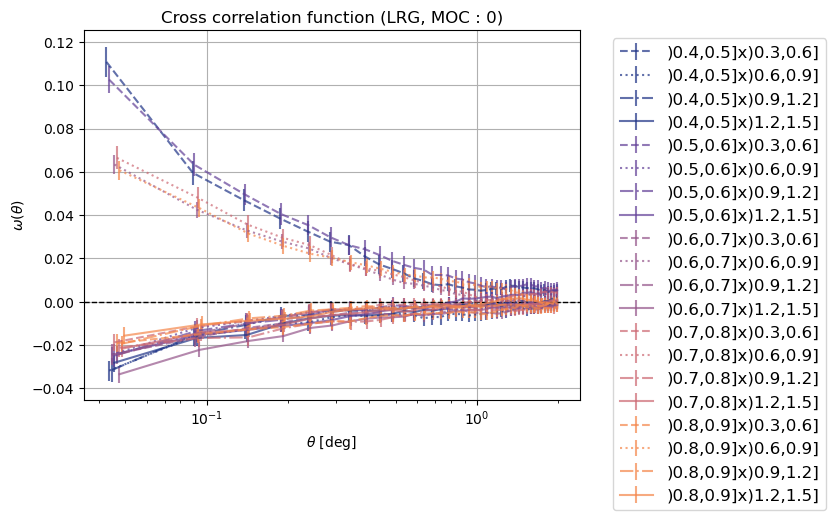

In [50]:
tgt = 'LRG'
bhsc = file_reader.get_bins('HSC')
btgt = file_reader.get_bins(tgt)

for i in range(1, 6):
    for j in range(1, len(bhsc)):
        try:
            result = TwoPointCorrelationFunction.load(
                file_reader.get_file(i, j, tgt, 'HSC', moc_idx)
                )
        except:
            continue
        ls = '-' 
        if j == 1:
            ls = '--'
        if j == 2:
            ls = ':'
        if j == 3:
            ls = '-.'
        plt.errorbar(
            result.sep+0.001*j+0.001*i, 
            result.corr, 
            yerr=np.sqrt(np.diag(result.cov())),
            alpha=0.7,
            linestyle=ls,
            label=f'){btgt[i-1]:.1f},{btgt[i]:.1f}]x){bhsc[j-1]:.1f},{bhsc[j]:.1f}]',
            color=cmap(i/(len(btgt)-1)),
            )
plt.xscale('log')
plt.title(f'Cross correlation function ({tgt}, MOC : {moc_idx})', fontsize=12)
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\omega(\theta)$')
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.grid()

<Axes: xlabel='$\\theta$ [deg]', ylabel='$\\theta w(\\theta)$'>

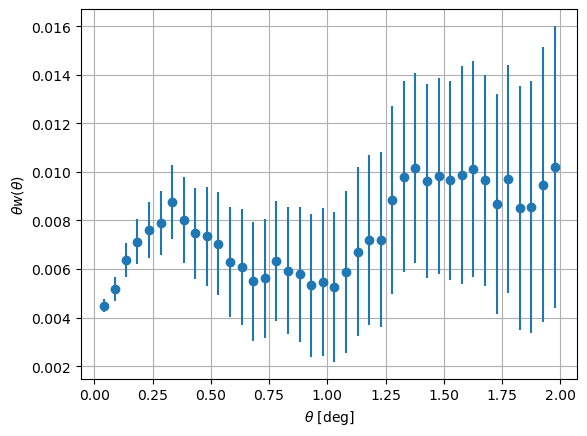

In [38]:
file = file_reader.get_file(1, 1, tgt, 'HSC', 0)
binqso = file_reader.get_bins('QSO')
binhsc = file_reader.get_bins('HSC')
result = TwoPointCorrelationFunction.load(file)
result.plot()

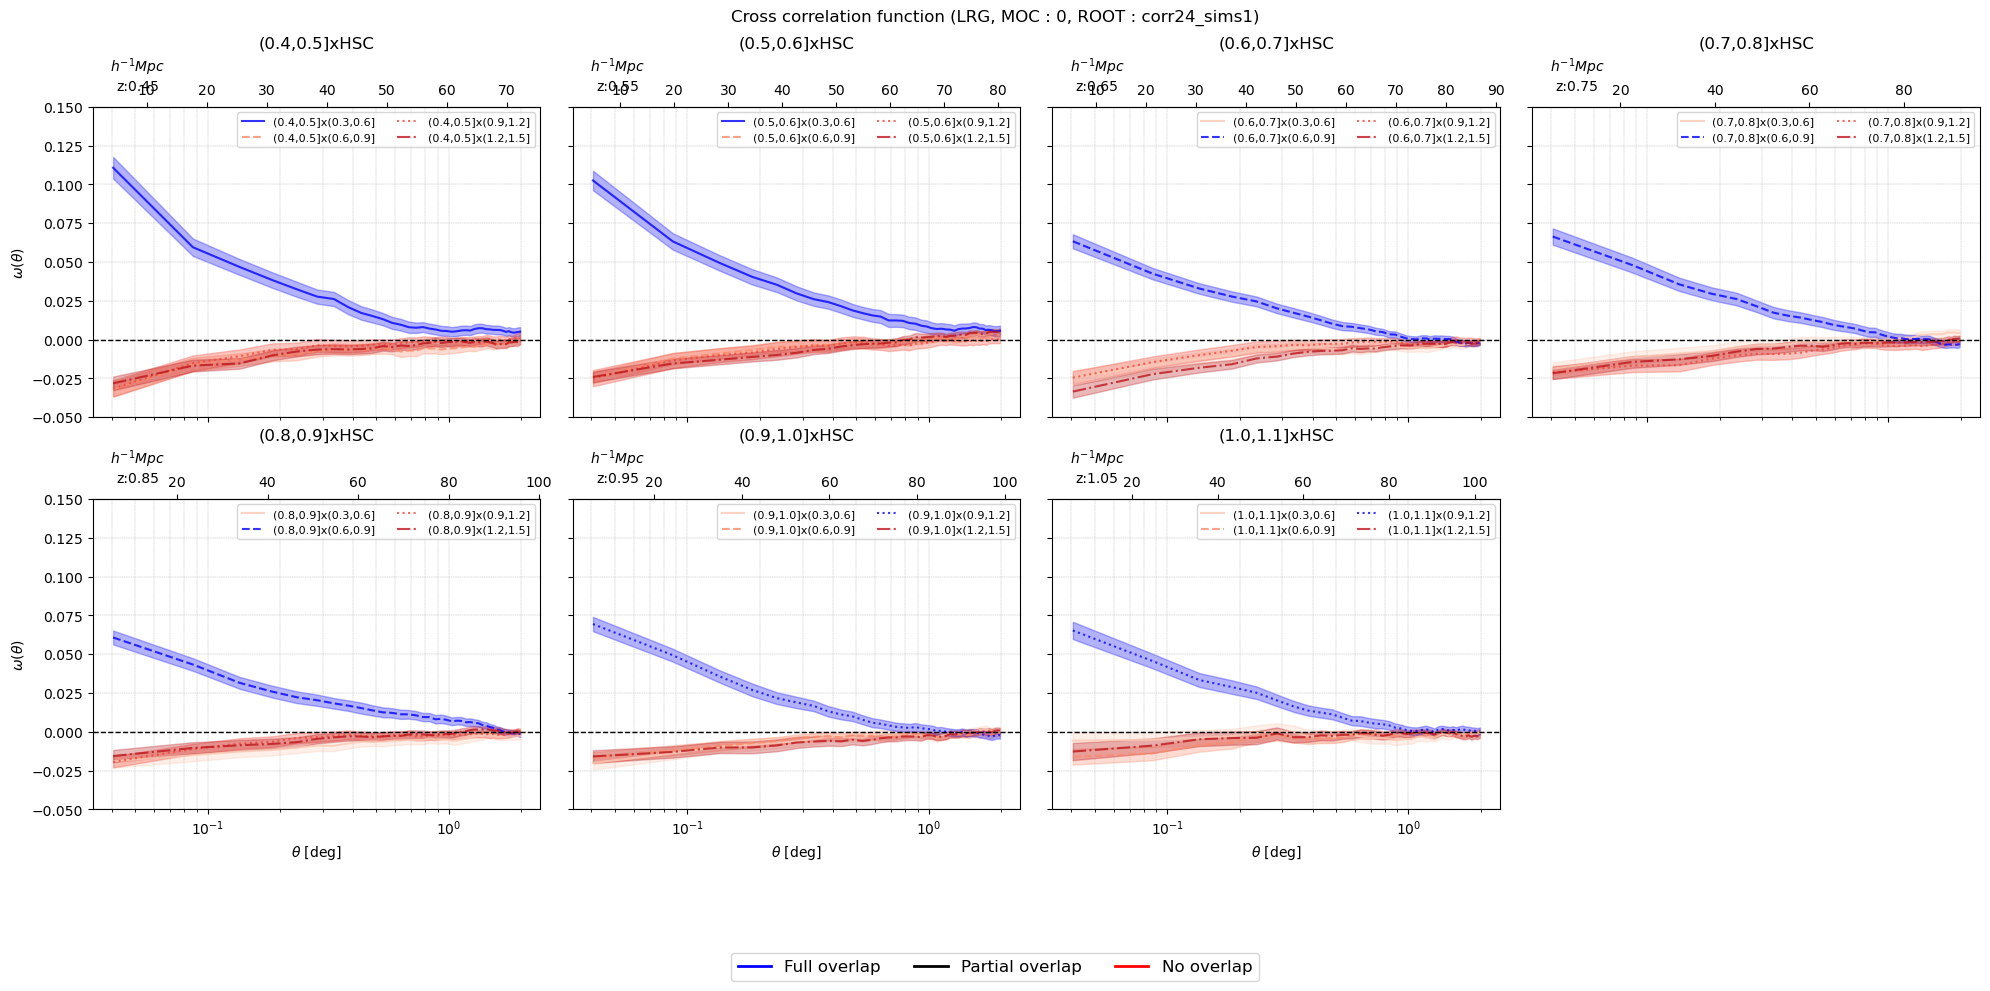

In [51]:
importlib.reload(cu)
#file_reader = cu.CorrFileReader('../crosscorr/corr23bgs/')
tgt = 'LRG'
thetamult = False

# (2, 4) for ELGnotqso
# (2, 4) for LRG (remove last)
# (1, 4) for QSO
nrows = 2
ncols = 4
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*5), sharex=True, sharey=True)
bins_tgt = file_reader.get_bins(tgt)
bins_hsc = file_reader.get_bins('HSC')
axs = axs.flatten()

exit_plot = False
for i in range(1, len(bins_tgt)):
    for j in range(1, len(bins_hsc)):
        try:
            ax = axs[i-1]
        except IndexError:
            exit_plot = True
        try:
            cov_result = TwoPointCorrelationFunction.load(
                file_reader.get_file(i, j, tgt, 'HSC', moc_idx)
                )
        except FileNotFoundError:
            #print(f'File not found for {i}, {j}')
            continue
        
        # Define bin edges
        btgt_min, btgt_max = bins_tgt[i-1], bins_tgt[i]
        bhsc_min, bhsc_max = bins_hsc[j-1], bins_hsc[j]

        # Check overlap conditions
        if bhsc_min <= btgt_min+1e-5 and bhsc_max >= btgt_max-1e-5 :
            color = 'blue'  # Full overlap
        elif bhsc_max <= btgt_min+1e-5  or bhsc_min >= btgt_max-1e-5 :
            color = plt.get_cmap('Reds')(j/len(bins_hsc))   # No overlap
        else:
            color = 'black' # Partial overlap

        ls = '-' 
        if j == 2:
            ls = '--'
        if j == 3:
            ls = ':'
        if j == 4:
            ls = '-.'

        sep = cov_result.sep
        cov = cov_result.cov()

        corrcoef = utils.cov_to_corrcoef(cov=cov)
        jackerr = np.sqrt(np.diag(cov))

        ax.fill_between(
            cov_result.sep,
            (cov_result.sep if thetamult else 1)*(cov_result.corr-jackerr),
            (cov_result.sep if thetamult else 1)*(cov_result.corr+jackerr),
            color=color,
            alpha=0.3
        )
        ax.plot(
            cov_result.sep,
            (cov_result.sep if thetamult else 1)*cov_result.corr,
            color=color,
            linestyle=ls,
            alpha=0.8,
            label=f'({bins_tgt[i-1]:.1f},{bins_tgt[i]:.1f}]x({bins_hsc[j-1]:.1f},{bins_hsc[j]:.1f}]'
        )
    if not exit_plot:
        if i > 4:
            ax.set_xlabel(r'$\theta$ [deg]')
        if i == 1 or i == 5:
            ax.set_ylabel(r'$\omega(\theta)$' if not thetamult else r'$\theta \omega(\theta)$')

        ax.grid(True, which='both', linestyle='--', lw=0.3)
        ax.set_xscale('log')
        ax.axhline(0, color='k', linestyle='--', lw=1)
        ax.set_title(f'({bins_tgt[i-1]:.1f},{bins_tgt[i]:.1f}]xHSC', fontsize=12)
        ax.legend(loc='upper right', fontsize=8, ncols=2)

        mid_z = (bins_tgt[i-1] + bins_tgt[i]) / 2
        tohMpc = lambda x, z=mid_z: ct.arcsec2hMpc(x * 3600, z=z)
        toArcsec = lambda theta, z=mid_z: ct.hMpc2arcsec(theta, z=z) / 3600

        ax.set_ylim(-0.05, 0.15)
        secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
        secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz:{mid_z:.2f}\n')
        secax.set_xscale('linear')
        secax.xaxis.set_label_coords(0.1, 0)

fig.suptitle(f'Cross correlation function ({tgt}, MOC : {moc_idx}, ROOT : {Path(file_reader.ROOT).stem})', fontsize=12)
fig.tight_layout()

# overlap types
custom_lines = [
    mlines.Line2D([0], [0], color='blue', lw=2),
    mlines.Line2D([0], [0], color='black', lw=2),
    mlines.Line2D([0], [0], color='red', lw=2)
    ]
fig.legend(
    custom_lines, 
    [
        'Full overlap', 
        'Partial overlap', 
        'No overlap'
        ], 
    loc='lower center', 
    ncol=3, 
    bbox_to_anchor=(0.5, 0), 
    fontsize=12
    )
if tgt == 'LRG':
    fig.delaxes(axs[-1])
plt.subplots_adjust(bottom=0.18)
plt.show()

In [18]:
np.linspace(0.001, 2, 41)

array([1.000000e-03, 5.097500e-02, 1.009500e-01, 1.509250e-01,
       2.009000e-01, 2.508750e-01, 3.008500e-01, 3.508250e-01,
       4.008000e-01, 4.507750e-01, 5.007500e-01, 5.507250e-01,
       6.007000e-01, 6.506750e-01, 7.006500e-01, 7.506250e-01,
       8.006000e-01, 8.505750e-01, 9.005500e-01, 9.505250e-01,
       1.000500e+00, 1.050475e+00, 1.100450e+00, 1.150425e+00,
       1.200400e+00, 1.250375e+00, 1.300350e+00, 1.350325e+00,
       1.400300e+00, 1.450275e+00, 1.500250e+00, 1.550225e+00,
       1.600200e+00, 1.650175e+00, 1.700150e+00, 1.750125e+00,
       1.800100e+00, 1.850075e+00, 1.900050e+00, 1.950025e+00,
       2.000000e+00])

In [22]:
np.logspace(
    np.log(0.001), 
    np.log(2), 
    41,
    base=np.e
    )

array([1.00000000e-03, 1.20927688e-03, 1.46235057e-03, 1.76838674e-03,
       2.13846920e-03, 2.58600136e-03, 3.12719166e-03, 3.78164058e-03,
       4.57305052e-03, 5.53008427e-03, 6.68740305e-03, 8.08692190e-03,
       9.77932769e-03, 1.18259149e-02, 1.43008054e-02, 1.72936334e-02,
       2.09127911e-02, 2.52893547e-02, 3.05818320e-02, 3.69819024e-02,
       4.47213595e-02, 5.40805062e-02, 6.53983058e-02, 7.90846592e-02,
       9.56352500e-02, 1.15649497e-01, 1.39852263e-01, 1.69120108e-01,
       2.04513037e-01, 2.47312887e-01, 2.99069756e-01, 3.61658142e-01,
       4.37344830e-01, 5.28870991e-01, 6.39551462e-01, 7.73394797e-01,
       9.35248448e-01, 1.13097433e+00, 1.36766110e+00, 1.65388095e+00,
       2.00000000e+00])

In [33]:
from pycorr import utils
import cmocean.cm as cmo

importlib.reload(cu)
file_reader = cu.CorrFileReader('../crosscorr/old/run17jk/')
tgt = 'LRG' #'ELGnotqso'
moc_idx = 1
print(cu.moc_list[moc_idx])

# (2, 4) for ELGnotqso
# (2, 4) for LRG
fig, axs = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
bins_tgt = file_reader.get_bins(tgt)
bins_hsc = file_reader.get_bins('HSC')
axs = axs.flatten()

for i in range(1, len(bins_tgt)):

    for j in range(1, len(bins_hsc)):
        ax = axs[i-1]
        try:
            result = TwoPointCorrelationFunction.load(
                file_reader.get_cov_file(i, j, moc_idx, tgt)
                )
            cov = result.cov()
        except FileNotFoundError:
            cov = np.zeros((len(result.sep), len(result.sep)))
        
        # Define bin edges
        btgt_min, btgt_max = bins_tgt[i-1], bins_tgt[i]
        bhsc_min, bhsc_max = bins_hsc[j-1], bins_hsc[j]

        # Check overlap conditions
        if bhsc_min <= btgt_min+1e-5 and bhsc_max >= btgt_max-1e-5 :
            color = 'blue'  # Full overlap
        elif bhsc_max <= btgt_min+1e-5  or bhsc_min >= btgt_max-1e-5 :
            color = 'red'   # No overlap
        else:
            color = 'green' # Partial overlap

        ls = '-' 
        if j == 2:
            ls = '--'
        if j == 3:
            ls = ':'
        if j == 4:
            ls = '-.'

        sep = result.sep

        corrcoef = utils.cov_to_corrcoef(cov=cov)
        jackerr = np.sqrt(np.diag(cov))

        ax.fill_between(
            result.sep,
            result.corr-jackerr,
            result.corr+jackerr,
            color=color,
            alpha=0.3
        )
        ax.plot(
            result.sep,
            result.corr,
            color=color,
            linestyle=ls,
            alpha=0.8,
            label=f'({bins_tgt[i-1]:.1f},{bins_tgt[i]:.1f}]x({bins_hsc[j-1]:.1f},{bins_hsc[j]:.1f}]'
        )

    if i > 4:
        ax.set_xlabel(r'$\theta$ [deg]')
    if i == 1 or i == 5:
        ax.set_ylabel(r'$\omega(\theta)$')

    ax.grid(True, which='both', linestyle='--', lw=0.3)
    ax.set_xscale('log')
    ax.axhline(0, color='k', linestyle='--', lw=1)
    ax.set_title(f'({bins_tgt[i-1]:.1f},{bins_tgt[i]:.1f}]xHSC', fontsize=12)
    ax.legend(loc='upper right', fontsize=8, ncols=2)

    mid_z = (bins_tgt[i-1] + bins_tgt[i]) / 2
    tohMpc = lambda x, z=mid_z: ct.arcsec2hMpc(x * 3600, z=z)
    toArcsec = lambda theta, z=mid_z: ct.hMpc2arcsec(theta, z=z) / 3600

    secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
    secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz : {mid_z:.2f}\n')
    secax.xaxis.set_label_coords(0.1, 0)

fig.suptitle(f'Cross correlation function ({tgt}, MOC : {moc_idx})', fontsize=12)
fig.tight_layout()

# overlap types
custom_lines = [
    mlines.Line2D([0], [0], color='blue', lw=2),
    mlines.Line2D([0], [0], color='green', lw=2),
    mlines.Line2D([0], [0], color='red', lw=2)
    ]
fig.legend(
    custom_lines, 
    [
        'Full overlap', 
        'Partial overlap', 
        'No overlap'
        ], 
    loc='lower center', 
    ncol=3, 
    bbox_to_anchor=(0.5, 0), 
    fontsize=12
    )
if tgt == 'LRG':
    fig.delaxes(axs[-1])
plt.subplots_adjust(bottom=0.18)
plt.show()

AttributeError: module 'scripts.statistics.corrutils' has no attribute 'moc_list'

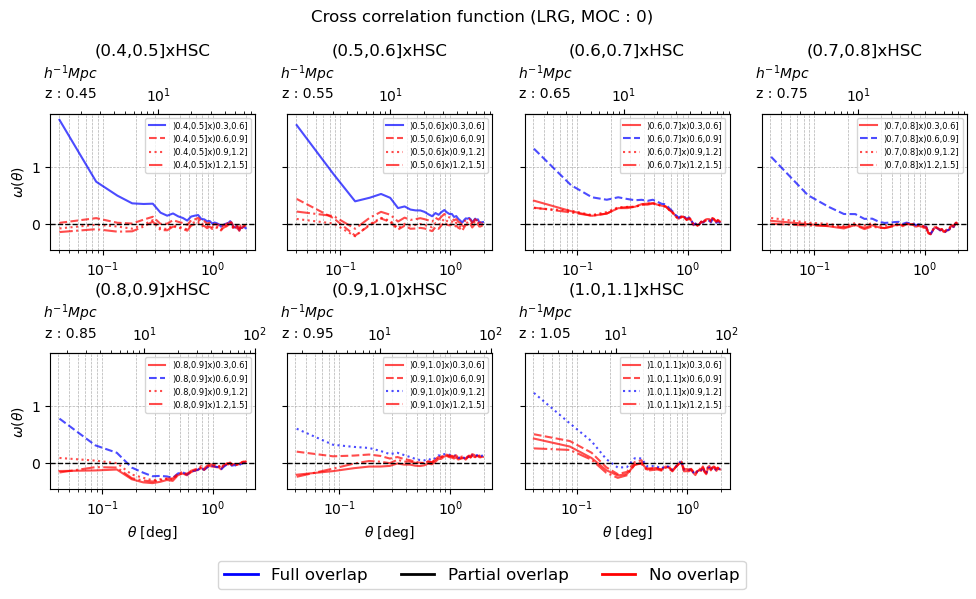

In [22]:
file_reader = cu.CorrFileReader('../crosscorr/run19/')
tgt = 'LRG'
bhsc = file_reader.get_bins('HSC')
btgt = file_reader.get_bins(tgt)
moc_idx = 0

cmap = plt.get_cmap('rainbow')
fig, axs = plt.subplots(2, 4, sharey=True, figsize=(10, 6))

axs = axs.flatten()
if tgt == 'LRG':
    fig.delaxes(axs[-1])
axs = axs[:len(btgt)-1]

for i, ax in enumerate(axs, start=1):
    for j in range(1, len(bhsc)):
        result = TwoPointCorrelationFunction.load(
            file_reader.get_file(i, j, moc_idx, tgt)
        )
        
        # Define bin edges
        btgt_min, btgt_max = btgt[i-1], btgt[i]
        bhsc_min, bhsc_max = bhsc[j-1], bhsc[j]

        # Check overlap conditions
        if bhsc_min <= btgt_min and bhsc_max >= btgt_max:
            color = 'blue'  # Full overlap
        elif bhsc_max <= btgt_min or bhsc_min >= btgt_max:
            color = 'red'   # No overlap
        else:
            color = 'black' # Partial overlap
        ls = '-' 
        if j == 2:
            ls = '--'
        if j == 3:
            ls = ':'
        if j == 4:
            ls = '-.'
        ax.plot(
            result.sep, 
            result.corr, 
            alpha=0.7,
            linestyle=ls,
            label=f'){btgt[i-1]:.1f},{btgt[i]:.1f}]x){bhsc[j-1]:.1f},{bhsc[j]:.1f}]',
            color=color,
            )
        if i > 4:
            ax.set_xlabel(r'$\theta$ [deg]')
        if i == 1 or i == 5:
            ax.set_ylabel(r'$\omega(\theta)$')

    ax.grid(True, which='both', linestyle='--', lw=0.5)
    ax.set_xscale('log')
    ax.axhline(0, color='k', linestyle='--', lw=1)
    ax.set_title(f'({btgt[i-1]:.1f},{btgt[i]:.1f}]xHSC', fontsize=12)
    ax.legend(loc='upper right', fontsize=6)

    mid_z = (btgt[i-1] + btgt[i]) / 2
    tohMpc = lambda x, z=mid_z: ct.arcsec2hMpc(x * 3600, z=z)
    toArcsec = lambda theta, z=mid_z: ct.hMpc2arcsec(theta, z=z) / 3600

    secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
    secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz : {mid_z:.2f}\n')
    secax.xaxis.set_label_coords(0.1, 1.1)
            
fig.suptitle(f'Cross correlation function ({tgt}, MOC : {moc_idx})', fontsize=12)
fig.tight_layout()

# overlap types
custom_lines = [
    mlines.Line2D([0], [0], color='blue', lw=2),
    mlines.Line2D([0], [0], color='black', lw=2),
    mlines.Line2D([0], [0], color='red', lw=2)
    ]
fig.legend(
    custom_lines, 
    [
        'Full overlap', 
        'Partial overlap', 
        'No overlap'
        ], 
    loc='lower center', 
    ncol=3, 
    bbox_to_anchor=(0.5, 0), 
    fontsize=12
    )
plt.subplots_adjust(bottom=0.18)

In [16]:
table = fio.FITS(Path(
                    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
                    ))

In [18]:
pz = table[1]['dnnz_photoz_best'].read()

Text(0.5, 1.0, 'Photo-z distribution (HSC)')

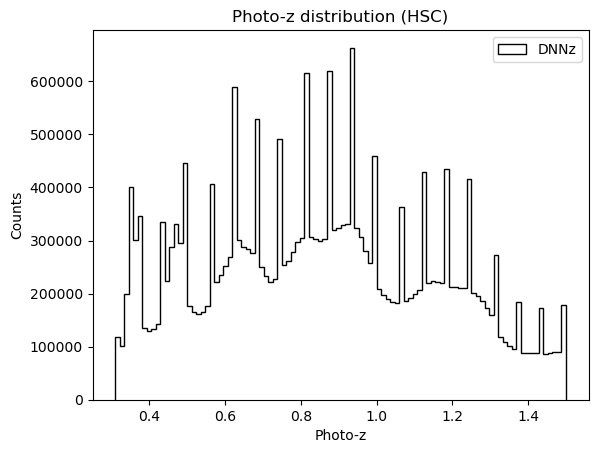

In [19]:
plt.hist(pz, bins=100, histtype='step', color='k', lw=2, label='DNNz')
plt.xlabel('Photo-z')
plt.ylabel('Counts')
plt.legend()
plt.title('Photo-z distribution (HSC)')

In [ ]:
import fitsio as fio
import os

os.listdir('/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/')

In [82]:
tbl = fio.FITS(
    '/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_clustering.dat.fits'
    )

In [83]:
sz = tbl[1]['Z'].read()

In [87]:
min(sz), max(sz)

(0.8000000181478555, 1.5999997110135349)

In [ ]:
len(sz)
bins_bgs = np.arange(0, 0.6, 0.1) # 0 < z < 0.6
bins_lrg = np.arange(0.4, 1.2, 0.1) # 0.4 < z < 1
bhsc = np.arange(0.8, 1.7, 0.1) # 0.6 < z < 1.6 => 0.8 < z < 1.6 in redshift distribution
bins_qso = np.arange(0.8, 3.4, 0.1) # 0.9 < z < 2.1

Text(0.5, 1.0, 'ELGnotqso redshift distribution')

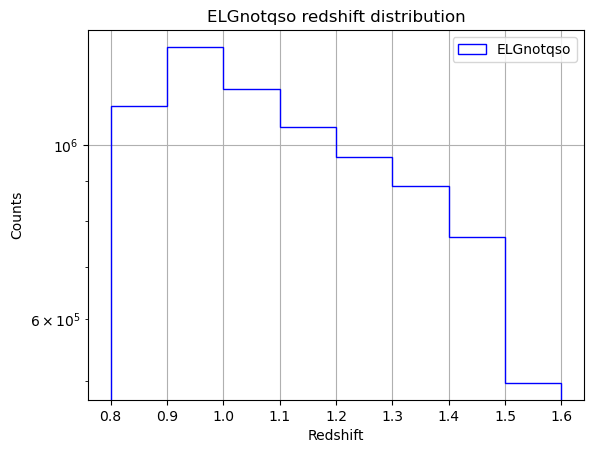

In [ ]:
plt.hist(sz, bins=bhsc, histtype='step', color='blue', lw=2, label='ELGnotqso')
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('ELGnotqso redshift distribution')

In [20]:
cat = fio.FITS(
    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
    )
cat[1].get_colnames()
pz = cat[1]['dnnz_photoz_best'].read()

1.5 0.31


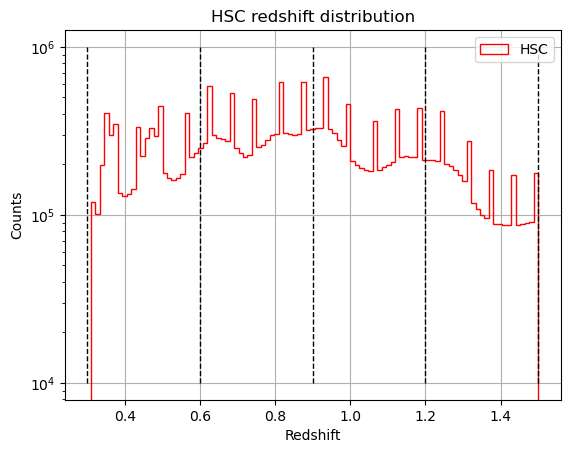

In [26]:
#bins_hsc = np.arange(0.3, 1.8, 0.3)
plt.hist(pz, bins=100, histtype='step', color='red', lw=2, label='HSC')
plt.vlines(
    [0.3, 0.6, 0.9, 1.2, 1.5], 
    ymin=1e4, ymax=1e6,
    color='black', linestyle='--', lw=1
    )
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('HSC redshift distribution')
print(max(pz), min(pz))